# Week 1: Data Loading and Exploration

**Project:** How Data-Quality Defects Affect Credit-Risk Models and Their Explanations

**Goal this week:** load the dataset, understand it, document its existing quality issues, and save a clean baseline that every later experiment starts from.

**Dataset:** *Default of Credit Card Clients* (Yeh & Lien, 2009), UCI ML Repository id 350. 30,000 credit-card clients in Taiwan, 23 features, binary target: did the client default the next month?

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Works whether you open this notebook from the repo root or from notebooks/
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_raw, clean, FEATURES, TARGET, PAY_STATUS

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

Matplotlib is building the font cache; this may take a moment.


## 2. Load the raw data

`load_raw` first looks for a file in `data/raw/`. If there is none, it downloads the data with `ucimlrepo` and caches it.

In [2]:
raw = load_raw(ROOT / "data" / "raw")
print(raw.shape)
raw.head()

Downloaded from UCI and cached in data/raw/
(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 3. First checks: types, missing values, duplicates

In [3]:
print("Rows, columns:", raw.shape)
print("Missing values in total:", int(raw.isna().sum().sum()))
print("Exact duplicate rows:", int(raw.duplicated().sum()))
raw.describe().T

Rows, columns: (30000, 24)
Missing values in total: 0
Exact duplicate rows: 35


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


## 4. Target balance

Most clients do not default, so the classes are imbalanced. This matters later: plain accuracy would be misleading, which is why the project uses AUC and the Brier score.

Default rate: 22.1%  (6,636 of 30,000 clients)


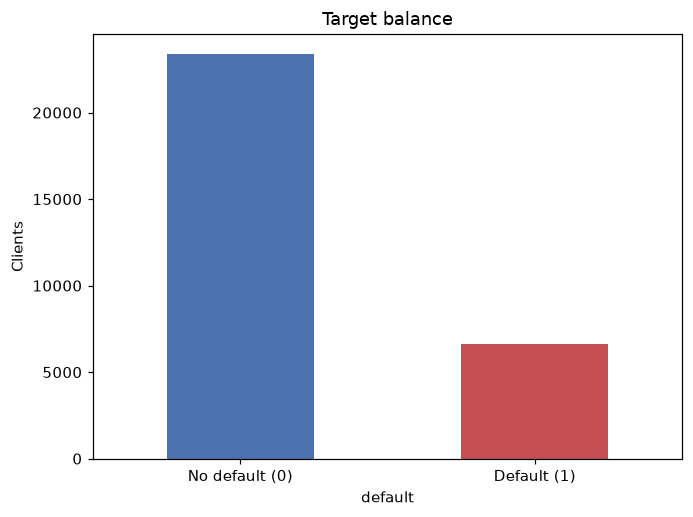

In [4]:
rate = raw[TARGET].mean()
print(f"Default rate: {rate:.1%}  ({raw[TARGET].sum():,} of {len(raw):,} clients)")

ax = raw[TARGET].value_counts().sort_index().plot.bar(color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["No default (0)", "Default (1)"], rotation=0)
ax.set_ylabel("Clients"); ax.set_title("Target balance")
plt.tight_layout(); plt.savefig(FIG_DIR / "w1_target_balance.png"); plt.show()

## 5. Existing data-quality issues in a "clean" benchmark

This section is important for the research story. The dataset is widely treated as clean, but several columns contain codes that the official documentation does not define:

- **EDUCATION**: documented 1–4, but 0, 5 and 6 also appear.
- **MARRIAGE**: documented 1–3, but 0 also appears.
- **PAY_0 … PAY_6**: documented −1 and 1–9, but −2 and 0 also appear, very often.

In [5]:
for col in ["EDUCATION", "MARRIAGE"]:
    print(col, raw[col].value_counts().sort_index().to_dict())

pay_codes = pd.DataFrame({c: raw[c].value_counts() for c in PAY_STATUS}).fillna(0).astype(int).sort_index()
pay_codes

EDUCATION {0: 14, 1: 10585, 2: 14030, 3: 4917, 4: 123, 5: 280, 6: 51}
MARRIAGE {0: 54, 1: 13659, 2: 15964, 3: 323}


,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19
7,9,20,27,58,58,46


## 6. Clean baseline

Decisions (all logged by `clean`):
- Undocumented EDUCATION codes are merged into 4 (*others*); undocumented MARRIAGE codes into 3 (*others*).
- PAY codes −2 and 0 are **kept**. They are frequent and predictive, and removing them would discard most of the data.
- Nothing is dropped or imputed, so the baseline stays as close to the original as possible.

In [6]:
df, log = clean(raw)
for line in log:
    print("-", line)

- EDUCATION: 345 rows with undocumented codes [0, 5, 6] -> mapped to 4 (others)
- MARRIAGE: 54 rows with undocumented codes [0] -> mapped to 3 (others)
- PAY_0: 17496 rows use undocumented codes -2/0 (kept as-is)
- PAY_2: 19512 rows use undocumented codes -2/0 (kept as-is)
- PAY_3: 19849 rows use undocumented codes -2/0 (kept as-is)
- PAY_4: 20803 rows use undocumented codes -2/0 (kept as-is)
- PAY_5: 21493 rows use undocumented codes -2/0 (kept as-is)
- PAY_6: 21181 rows use undocumented codes -2/0 (kept as-is)
- Exact duplicate rows (ID removed): 35 (kept; reported only)


## 7. Who defaults? Default rate by key variables

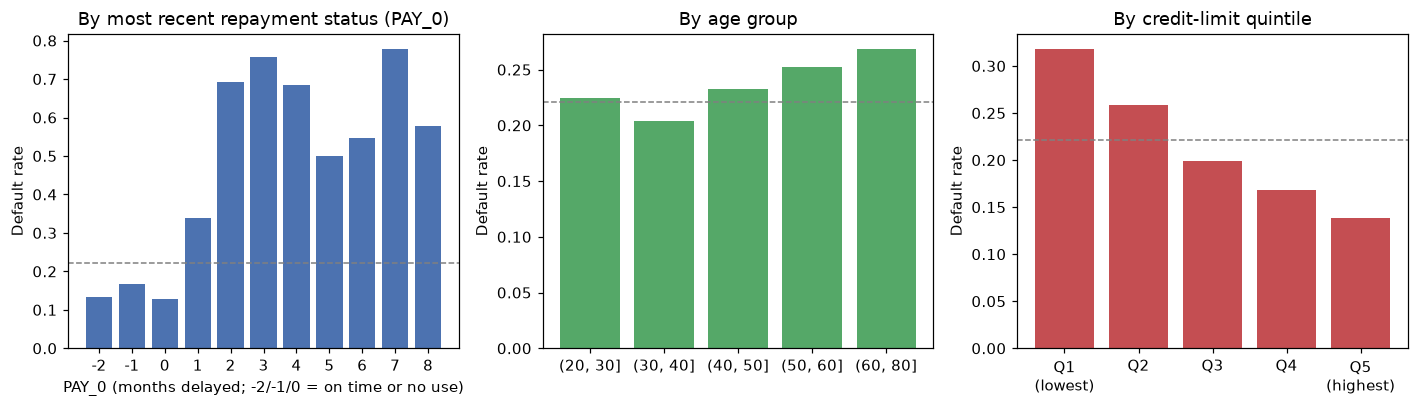

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

# Most recent repayment status
g = df.groupby("PAY_0")[TARGET].mean()
axes[0].bar(g.index.astype(str), g.values, color="#4C72B0")
axes[0].set_title("By most recent repayment status (PAY_0)")
axes[0].set_xlabel("PAY_0 (months delayed; -2/-1/0 = on time or no use)")

# Age group
age_grp = pd.cut(df["AGE"], [20, 30, 40, 50, 60, 80])
g = df.groupby(age_grp, observed=True)[TARGET].mean()
axes[1].bar(g.index.astype(str), g.values, color="#55A868")
axes[1].set_title("By age group")

# Credit limit quintile
lim_q = pd.qcut(df["LIMIT_BAL"], 5)
g = df.groupby(lim_q, observed=True)[TARGET].mean()
axes[2].bar(range(5), g.values, color="#C44E52")
axes[2].set_xticks(range(5)); axes[2].set_xticklabels(["Q1\n(lowest)", "Q2", "Q3", "Q4", "Q5\n(highest)"])
axes[2].set_title("By credit-limit quintile")

for ax in axes:
    ax.set_ylabel("Default rate"); ax.axhline(df[TARGET].mean(), ls="--", c="gray", lw=1)
plt.tight_layout(); plt.savefig(FIG_DIR / "w1_default_rates.png"); plt.show()

Groups whose default rates differ sharply (for example low vs high credit limits) are natural candidates for the **distribution-shift experiment** in Week 4: train on one group, test on another.

## 8. Distributions of key numeric features

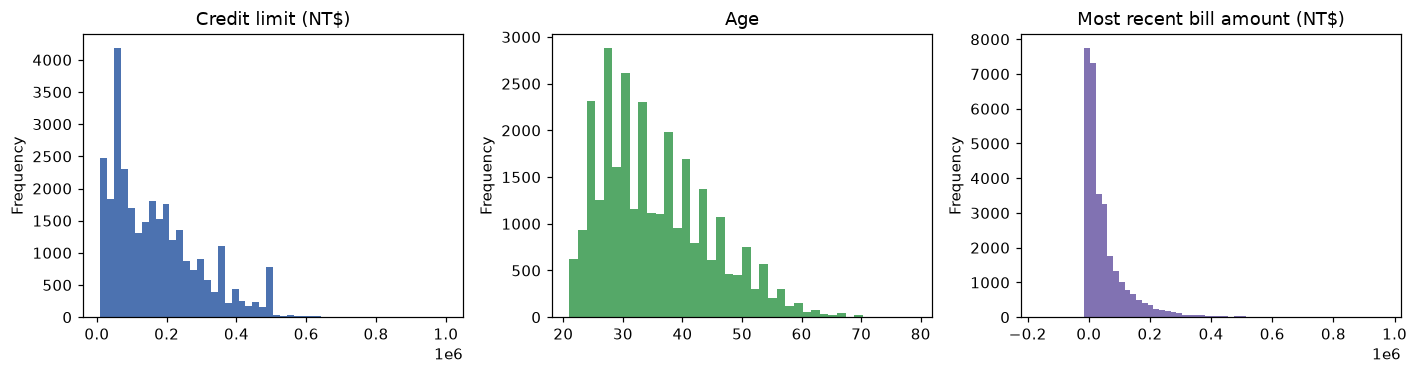

Negative bill amounts (credit balances): 1930 clients


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
df["LIMIT_BAL"].plot.hist(bins=50, ax=axes[0], color="#4C72B0", title="Credit limit (NT$)")
df["AGE"].plot.hist(bins=40, ax=axes[1], color="#55A868", title="Age")
df["BILL_AMT1"].plot.hist(bins=60, ax=axes[2], color="#8172B2", title="Most recent bill amount (NT$)")
plt.tight_layout(); plt.savefig(FIG_DIR / "w1_distributions.png"); plt.show()

print("Negative bill amounts (credit balances):", int((df[[f'BILL_AMT{i}' for i in range(1,7)]] < 0).any(axis=1).sum()), "clients")

## 9. Correlation with the target

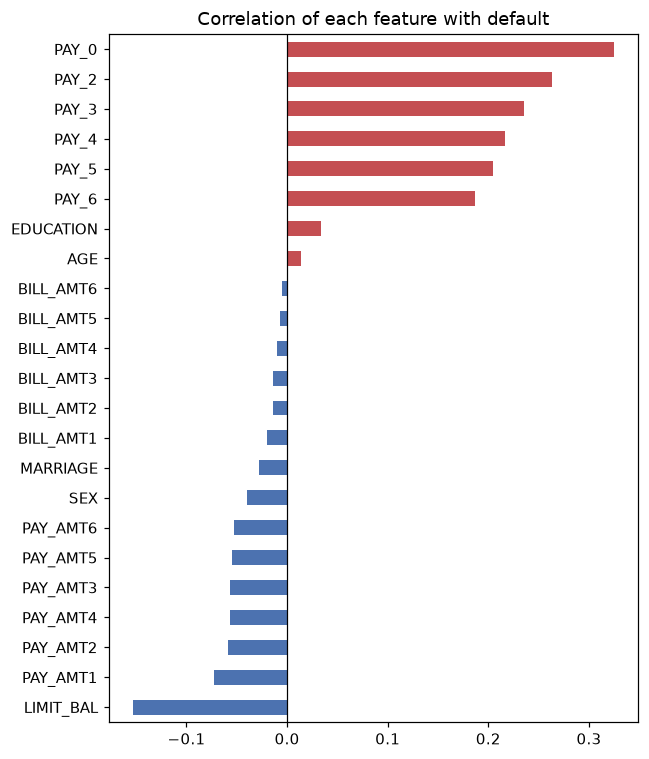

In [9]:
corr = df.corr(numeric_only=True)[TARGET].drop(TARGET).sort_values()
ax = corr.plot.barh(figsize=(6, 7), color=np.where(corr > 0, "#C44E52", "#4C72B0"))
ax.set_title("Correlation of each feature with default"); ax.axvline(0, c="k", lw=0.8)
plt.tight_layout(); plt.savefig(FIG_DIR / "w1_target_correlation.png"); plt.show()

Repayment-status features (PAY_*) are expected to be the strongest signals. In Week 2, check whether SHAP agrees. That clean-data ranking becomes the reference point for measuring explanation stability.

## 10. Save the clean baseline

In [10]:
out = ROOT / "data" / "processed" / "credit_clean.csv"
out.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(out, index=False)
print(f"Saved {df.shape} to {out.relative_to(ROOT)}")

Saved (30000, 24) to data/processed/credit_clean.csv


## 11. Week 1 findings

1. **Size and balance:** I found 30,000 clients and 23 features. About 22.1% defaulted, so a model that guessed “no default” for everyone would appear 77.9% accurate while missing every default.
2. **Undocumented codes found:** I found 345 clients with EDUCATION codes 0, 5, or 6, and 54 with MARRIAGE code 0. The undocumented codes −2 or 0 appear in 58.3% of PAY_0 values and 70.6% of PAY_6 values.
3. **Cleaning decisions and why:** I merged those EDUCATION codes into “others” (4) and MARRIAGE code 0 into “others” (3) to keep the clients without treating undocumented categories as known ones. I kept PAY codes −2 and 0 because they occur so often that removing affected rows would discard much of the data.
4. **Strongest signals of default:** I found the most recent repayment status, PAY_0, was the strongest signal in the correlation chart. About 69.1% of clients coded two months late defaulted, compared with 16.8% of those coded as paying on time (−1).
5. **Candidate groups for the distribution-shift experiment:** I found default rates of 31.8% in the lowest credit-limit group and 13.8% in the highest. These are useful groups for training on one and testing on the other.
6. **Questions or surprises:** I noticed code 1 appears 3,688 times in PAY_0, but only 28 times in PAY_2, four in PAY_3, two in PAY_4, and none in PAY_5 or PAY_6. This suggests the repayment codes may have been recorded differently across months, so I would check their meaning before interpreting that pattern.